In [ ]:
!pip install kagglehub
import kagglehub
import os
os.environ["KAGGLE_API_TOKEN"]=""

import shutil

cache_path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')
print("Downloaded to:", cache_path)

current_dir = os.getcwd()

if os.path.isdir(cache_path):
    for item in os.listdir(cache_path):
        source = os.path.join(cache_path, item)
        destination = os.path.join(current_dir, item)
        
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy(source, destination)
    print(f"copied all files to: {current_dir}")
else:
    shutil.copy(cache_path, current_dir)
    print(f"Copied file to: {current_dir}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 55.3 MB/s eta 0:00:00


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 120M/120M [00:06<00:00, 18.4MB/s] 

Extracting files...


Downloaded to: /root/.cache/kagglehub/competitions/ucsc-cse-144-spring-2026-final-project
copied all files to: /root


In [ ]:
!pip install -q open-clip-torch peft timm pandas matplotlib tqdm pillow


import os
import random
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets

import open_clip
from peft import LoraConfig, get_peft_model


import os
os.environ["HF_TOKEN"] = ""

print("Torch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.1
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Torch version: 2.2.1
Using device: cuda


In [3]:
train_dir = Path("train")
test_dir = Path("test")

image_paths = sorted(list(train_dir.glob("*/*.jpg")))

SIGLIP_MEAN = (0.5, 0.5, 0.5)
SIGLIP_STD = (0.5, 0.5, 0.5)

train_transforms = transforms.Compose([
    transforms.Resize((378, 378)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(SIGLIP_MEAN, SIGLIP_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((378, 378)),
    transforms.ToTensor(),
    transforms.Normalize(SIGLIP_MEAN, SIGLIP_STD),
])

In [4]:
full_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

idx_to_foldername = {v: k for k, v in full_dataset.class_to_idx.items()}
idx_to_true_class = {idx: int(foldername) for idx, foldername in idx_to_foldername.items()}

NUM_CLASSES = len(full_dataset.classes)
print(f"Train dataset size: {len(full_dataset)}, classes: {NUM_CLASSES}")

class_counts = np.bincount(full_dataset.targets)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

Train dataset size: 1079, classes: 100


In [5]:
val_size = int(len(full_dataset) * 0.15)
train_size = len(full_dataset) - val_size
generator = torch.Generator().manual_seed(42)

train_idx, val_idx = random_split(range(len(full_dataset)), [train_size, val_size], generator=generator)

In [6]:
train_set = torch.utils.data.Subset(full_dataset, train_idx)
val_set = torch.utils.data.Subset(full_dataset, val_idx)

BATCH_SIZE = 32  

train_loader = DataLoader(
    train_set, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_set, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

In [ ]:
class L2NormalizedCosineHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.scale = nn.Parameter(torch.tensor(20.0)) 
        
    def forward(self, x):
        x_norm = F.normalize(x, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        cosine_sim = F.linear(x_norm, weight_norm)
        return cosine_sim * self.scale

class Siglip2LoRAModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        print("Loading ViT-SO400M-14-SigLIP2-378")
        self.backbone, _, _ = open_clip.create_model_and_transforms(
            'ViT-SO400M-14-SigLIP2-378', 
            pretrained='webli'
        )
        self.visual = self.backbone.visual
        
        for param in self.visual.parameters():
            param.requires_grad = False
            
        num_blocks = len(self.visual.trunk.blocks)
        target_modules = []
        for i in range(num_blocks - 4, num_blocks):
            target_modules.append(f"trunk.blocks.{i}.attn.qkv")
        
        print(f"Applying peft LoRA adaptation onto the last 4 blocks: {list(range(num_blocks-4, num_blocks))}")
        peft_config = LoraConfig(
            r=16,
            lora_alpha=32,
            target_modules=target_modules,
            lora_dropout=0.05,
            bias="none"
        )
        self.visual = get_peft_model(self.visual, peft_config)
        
        in_features = 1152 
        self.classification_head = L2NormalizedCosineHead(in_features, num_classes)

    def forward(self, x):
        features = self.visual(x)
        return self.classification_head(features)

model = Siglip2LoRAModel(num_classes=NUM_CLASSES).to(device)


Loading ViT-SO400M-14-SigLIP2-378
Applying Parameter-Efficient LoRA adaptation onto the last 4 blocks: Blocks [23, 24, 25, 26]


In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4,
    weight_decay=1e-2
)

EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [9]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in tqdm(loader, desc="Training Batches", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return total_loss / total, correct / total

In [10]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return total_loss / total, correct / total


In [11]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
ckpt_path = "./checkpoints/best_siglip2_lora.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} || "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch}, ckpt_path)
        print(f"--- New checkpoint saved with Validation Accuracy: {best_val_acc:.4f} ---")

print("training done")

Epoch [1/20] -> Train Loss: 4.1211 | Train Acc: 0.1819 || Val Loss: 3.1454 | Val Acc: 0.5031
--- New checkpoint saved with Validation Accuracy: 0.5031 ---


Epoch [2/20] -> Train Loss: 2.1696 | Train Acc: 0.7495 || Val Loss: 1.4716 | Val Acc: 0.8323
--- New checkpoint saved with Validation Accuracy: 0.8323 ---


Epoch [3/20] -> Train Loss: 0.8730 | Train Acc: 0.9161 || Val Loss: 0.6952 | Val Acc: 0.8944
--- New checkpoint saved with Validation Accuracy: 0.8944 ---


Epoch [4/20] -> Train Loss: 0.4194 | Train Acc: 0.9499 || Val Loss: 0.4246 | Val Acc: 0.9068
--- New checkpoint saved with Validation Accuracy: 0.9068 ---


Epoch [5/20] -> Train Loss: 0.2531 | Train Acc: 0.9641 || Val Loss: 0.3522 | Val Acc: 0.9255
--- New checkpoint saved with Validation Accuracy: 0.9255 ---


...

Epoch [16/20] -> Train Loss: 0.0562 | Train Acc: 0.9956 || Val Loss: 0.1996 | Val Acc: 0.9441


Epoch [17/20] -> Train Loss: 0.0497 | Train Acc: 0.9946 || Val Loss: 0.2234 | Val Acc: 0.9379


Epoch [18/20] -> Train Loss: 0.0444 | Train Acc: 0.9967 || Val Loss: 0.1904 | Val Acc: 0.9627


Epoch [19/20] -> Train Loss: 0.0426 | Train Acc: 0.9978 || Val Loss: 0.1977 | Val Acc: 0.9503


Epoch [20/20] -> Train Loss: 0.0441 | Train Acc: 0.9978 || Val Loss: 0.2102 | Val Acc: 0.9441
training done


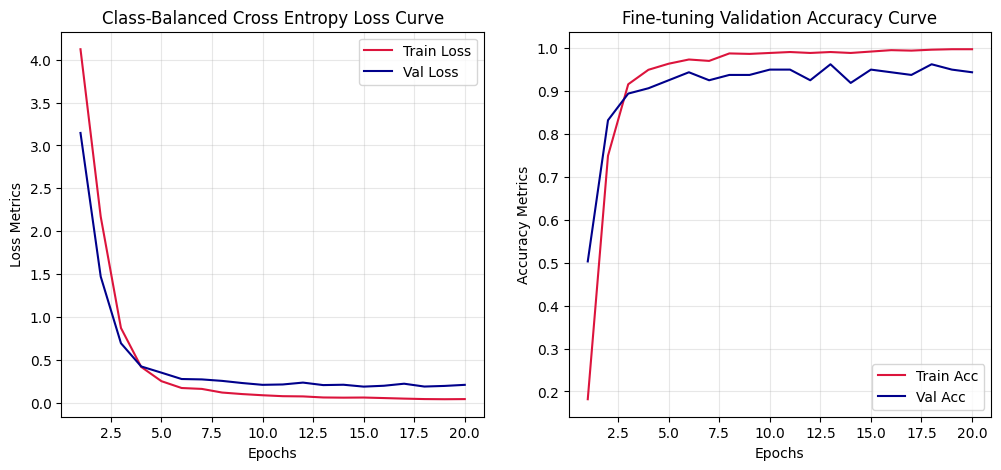

In [ ]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss", color='crimson')
plt.plot(epochs_range, history["val_loss"], label="Val Loss", color='darkblue')
plt.xlabel("Epochs")
plt.ylabel("Loss Metrics")
plt.title("Cross Entropy Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc", color='crimson')
plt.plot(epochs_range, history["val_acc"], label="Val Acc", color='darkblue')
plt.xlabel("Epochs")
plt.ylabel("Accuracy Metrics")
plt.title("Validation Accuracy Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [16]:
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


test_image_paths = sorted(list(test_dir.glob("*.jpg")), key=lambda p: int(p.stem))
ids, preds = [], []

with torch.no_grad():
    for img_path in tqdm(test_image_paths, desc="Test Inference"):
        img = Image.open(img_path).convert("RGB")
        x = val_transforms(img).unsqueeze(0).to(device)
        
        output = model(x)
        mapped_pred = output.argmax(dim=1).item()
        idx_to_true_class = {idx: int(foldername) for idx, foldername in idx_to_foldername.items()}
        original_class_id = idx_to_true_class[mapped_pred]
        
        ids.append(img_path.name)
        preds.append(original_class_id)

submission = pd.DataFrame({"ID": ids, "Label": preds})
out_path = Path("submission.csv")
submission.to_csv(out_path, index=False)

print(submission.head())

Test Inference: 100%|██████████| 1036/1036 [03:47<00:00,  4.55it/s]


      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
